In [1]:
import os
wdir=!echo $PWD
os.chdir("/home6/afahad/.ipython/")
from aoespy import *
os.chdir(wdir[0])

/home6/afahad/.ipython/aoespy.py:19: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
import xarray as xr
import ecco_v4_py as ecco
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from glob import glob
import os


#

In [3]:
ME506s=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_surf/200505/*surf*200505*z.nc4').sel(time=slice('2005-05-05','2005-06-30'))

In [4]:
ME506s2=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_surf/200506/*surf*200506*z.nc4').sel(time=slice('2005-05-05','2005-06-30'))

In [5]:
ME506=xr.concat([ME506s,ME506s2],dim='time')

In [6]:
olr=ME506.OLR.compute(scheduler='sync')
olr = olr.assign_coords(lon=((olr.lon + 360) % 360)).sortby("lon")

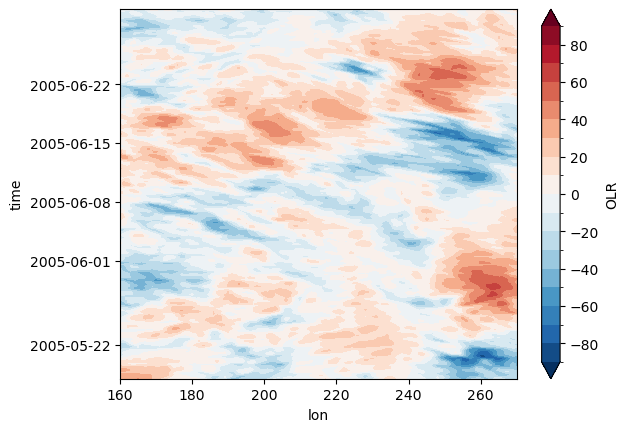

In [7]:
# Number of steps in 14 days for 3-hourly data
window = 12 * 8  # 112 steps

# Compute 14-day running mean (centered)
olr_14day_mean = olr.rolling(time=window, center=False).mean()

#olr=olr-olr.mean(dim='lon')
# Compute anomalies: original - running mean
olr_anom = olr - olr_14day_mean

# Optional: drop NaNs from edges caused by rolling
olr_anom = olr_anom.dropna(dim='time', how='all')

#olr_anom= olr_anom-olr_anom.mean(dim=['lon'])

# Save anomalies if needed
# olr_anom.to_netcdf("olr_14day_anomaly.nc")
#arange(-50,50.1,10)
olranom1=olr_anom.copy()
(olr_anom).sel(lat=slice(-15,15),lon=slice(160,270)).mean(dim='lat').plot.contourf(levels=20,extend='both')

In [8]:
olr_anom

<xarray.DataArray 'OLR' (time: 353, lat: 181, lon: 360)> Size: 92MB
array([[[ 4.50109100e+00,  4.50109100e+00,  4.50109100e+00, ...,
          4.50109100e+00,  4.50109100e+00,  4.50109100e+00],
        [-4.50093842e+00, -4.59661865e+00, -4.69141388e+00, ...,
         -4.20782471e+00, -4.30669403e+00, -4.40438843e+00],
        [-8.00205994e+00, -7.99574280e+00, -7.98955536e+00, ...,
         -8.02197266e+00, -8.01512146e+00, -8.00846100e+00],
        ...,
        [ 3.68882751e+00,  3.81176758e+00,  3.93667603e+00, ...,
          3.33222961e+00,  3.44923401e+00,  3.56809998e+00],
        [ 4.70901489e-01,  4.60723877e-01,  4.48318481e-01, ...,
          4.89685059e-01,  4.85321045e-01,  4.79125977e-01],
        [-1.25488281e-01, -1.25488281e-01, -1.25488281e-01, ...,
         -1.25488281e-01, -1.25488281e-01, -1.25488281e-01]],

       [[ 1.12547302e+01,  1.12547302e+01,  1.12547302e+01, ...,
          1.12547302e+01,  1.12547302e+01,  1.12547302e+01],
        [ 6.38427734e-01,  5.91964722e-01,  5.48889160e-01, ...,
          7.98889160e-01,  7.41790771e-01,  6.88308716e-01],
        [-8.05364227e+00, -8.06597900e+00, -8.07871246e+00, ...,
         -8.01876068e+00, -8.02999115e+00, -8.04161072e+00],
...
          9.72555542e+00,  9.73477173e+00,  9.74465942e+00],
        [ 1.12772522e+01,  1.12634583e+01,  1.12500458e+01, ...,
          1.13214111e+01,  1.13059540e+01,  1.12917633e+01],
        [ 1.03502655e+01,  1.03502655e+01,  1.03502655e+01, ...,
          1.03502655e+01,  1.03502655e+01,  1.03502655e+01]],

       [[-8.11111450e-01, -8.11111450e-01, -8.11111450e-01, ...,
         -8.11111450e-01, -8.11111450e-01, -8.11111450e-01],
        [-7.59124756e-03, -1.08337402e-02, -1.38397217e-02, ...,
          2.11334229e-03, -1.09100342e-03, -4.44030762e-03],
        [ 1.03125000e+00,  9.47029114e-01,  8.62464905e-01, ...,
          1.27917480e+00,  1.19741821e+00,  1.11477661e+00],
        ...,
        [ 9.21975708e+00,  9.24403381e+00,  9.26771545e+00, ...,
          9.15109253e+00,  9.17341614e+00,  9.19682312e+00],
        [ 1.12306061e+01,  1.12208405e+01,  1.12115631e+01, ...,
          1.12632141e+01,  1.12515259e+01,  1.12411804e+01],
        [ 1.00841980e+01,  1.00841980e+01,  1.00841980e+01, ...,
          1.00841980e+01,  1.00841980e+01,  1.00841980e+01]]],
      dtype=float32)
Coordinates:
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * time     (time) datetime64[ns] 3kB 2005-05-17T22:30:00 ... 2005-06-30T22:...
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0

In [9]:
ME416s=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0416/holding/geosgcm_surf/200504/*surf*200504*z.nc4')#.sel(time=slice('2005-04-05','2005-06-30'))

In [10]:
ME416s2=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0416/holding/geosgcm_surf/200505/*surf*200505*z.nc4')#.sel(time=slice('2005-04-05','2005-06-30'))

In [11]:
ME416=xr.concat([ME416s,ME416s2],dim='time')

In [12]:
olr2=ME416.OLR.compute(scheduler='sync')
olr2 = olr2.assign_coords(lon=((olr2.lon + 360) % 360)).sortby("lon")

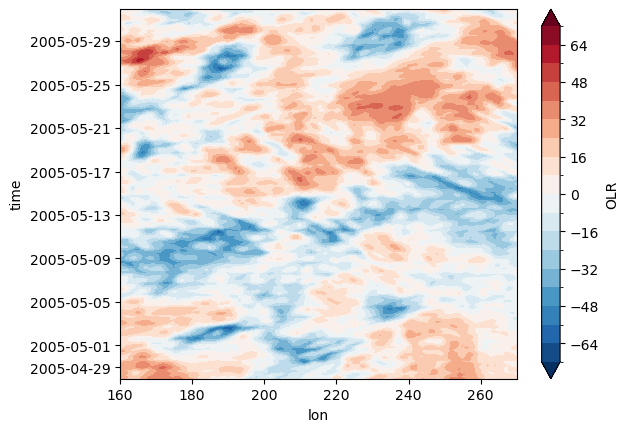

In [13]:
# Number of steps in 14 days for 3-hourly data
window = 12 * 8  # 112 steps

# Compute 14-day running mean (centered)
olr_14day_mean = olr2.rolling(time=window, center=False).mean()

#olr=olr-olr.mean(dim='lon')
# Compute anomalies: original - running mean
olr_anom = olr2 - olr_14day_mean

# Optional: drop NaNs from edges caused by rolling
olr_anom = olr_anom.dropna(dim='time', how='all')

#olr_anom= olr_anom-olr_anom.mean(dim=['lon'])

# Save anomalies if needed
# olr_anom.to_netcdf("olr_14day_anomaly.nc")
#arange(-50,50.1,10)
olranom2=olr_anom.copy()

(olr_anom).sel(lat=slice(-15,15),lon=slice(160,270)).mean(dim='lat').plot.contourf(levels=20,extend='both')

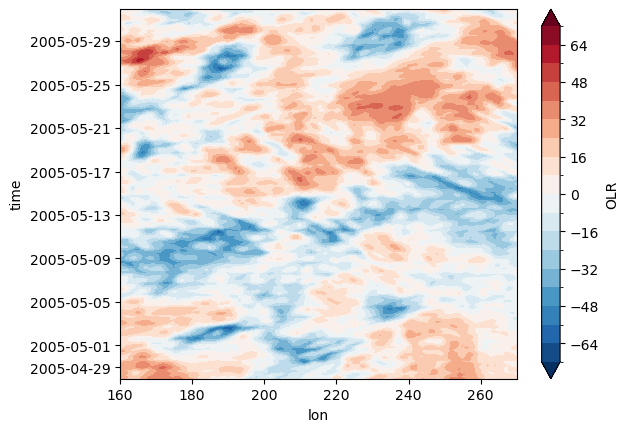

In [14]:
(olranom2).sel(lat=slice(-15,15),lon=slice(160,270)).mean(dim='lat').plot.contourf(levels=20,extend='both')

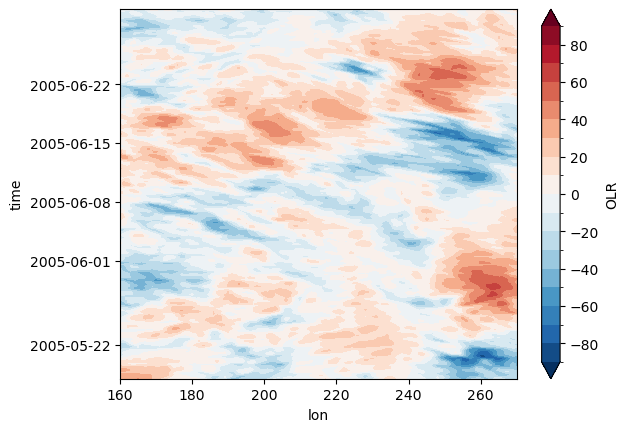

In [15]:
(olranom1).sel(lat=slice(-15,15),lon=slice(160,270)).mean(dim='lat').plot.contourf(levels=20,extend='both')

In [16]:
#wave=(olranom2.sel(time=slice('2005-05-06','2005-05-26')).data+olranom1.sel(time=slice('2005-06-01','2005-06-21')))/2

In [17]:
wave=(olranom2.sel(time=slice('2005-05-05','2005-05-20')).data+olranom1.sel(time=slice('2005-06-01','2005-06-16')))/2

In [18]:
wave=(olranom2.sel(time=slice('2005-05-03','2005-05-28')).data+olranom1.sel(time=slice('2005-05-30','2005-06-24')))/2

In [19]:
wave=wave.resample(time="1D").mean()
wave=wave.assign_coords(time=wave.time - pd.Timedelta(days=25))

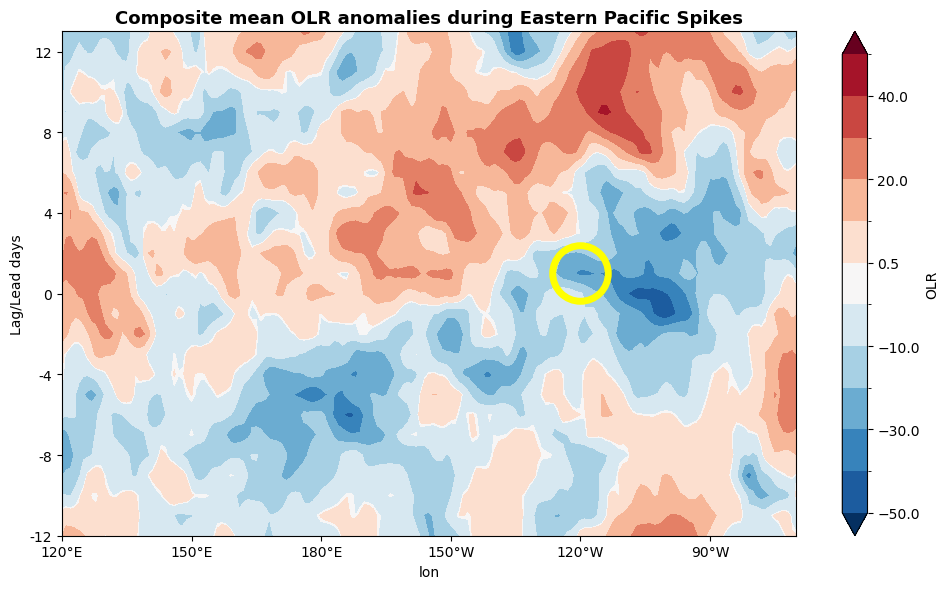

In [20]:
f()
(wave).sel(lat=slice(-15,15),lon=slice(120,290)).mean(dim='lat').plot.contourf(levels=array([-50,-40,-30,-20,-10,-.5,.5,10,20,30,40,50]),extend='both')
ax = plt.gca()
#ax.set_xlim()
# Custom longitude ticks
xticks = np.arange(120, 300, 30)  # adjust as needed
xtick_labels = []
for lon in xticks:
    if lon <= 180:
        xtick_labels.append(f"{lon:.0f}°E")
    else:
        xtick_labels.append(f"{360 - lon:.0f}°W")

ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)


# ----- Custom y-axis ticks as "Day N" -----
time_values = wave['time'].values
# Number days from 1
days_since_start = (pd.to_datetime(time_values) - pd.to_datetime(time_values[0])).days + 1

yticks = ax.get_yticks()
# Map yticks (which are dates) to day numbers
ytick_labels = []
for tick in yticks:
    try:
        day_number = (pd.to_datetime(tick) - pd.to_datetime(time_values[0])).days + 1
        ytick_labels.append(f"Day {day_number}")
    except Exception:
        ytick_labels.append("")  # blank if outside range
ax.set_yticks(yticks)
ax.set_yticklabels(arange(0,28,4)-12)
plt.ylabel('Lag/Lead days')

x_mark = 240  # 120°W in 0–360 coords
y_mark = pd.to_datetime(time_values[0]) + pd.Timedelta(days=13)

ax.plot(x_mark, y_mark, marker='o', markersize=40,color='yellow',
        markerfacecolor='none', markeredgewidth=5)


plt.title('Composite mean OLR anomalies during Eastern Pacific Spikes', fontsize= 13, fontweight='bold')
plt.tight_layout()
plt.savefig('olr_anom.png',dpi=150)
plt.show()

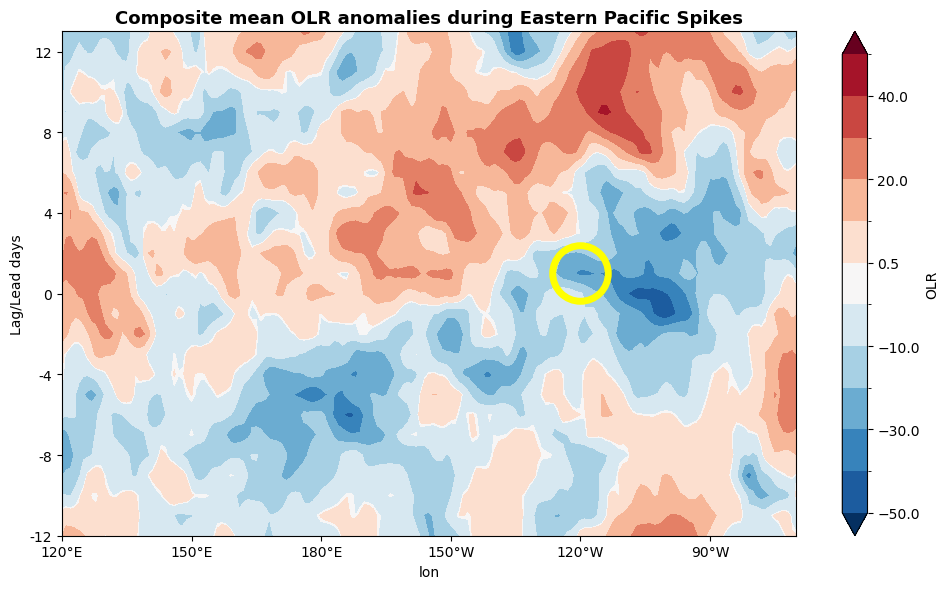

In [21]:
f()
(wave).sel(lat=slice(-15,15),lon=slice(120,290)).mean(dim='lat').plot.contourf(levels=array([-50,-40,-30,-20,-10,-.5,.5,10,20,30,40,50]),extend='both')
ax = plt.gca()
#ax.set_xlim()
# Custom longitude ticks
xticks = np.arange(120, 300, 30)  # adjust as needed
xtick_labels = []
for lon in xticks:
    if lon <= 180:
        xtick_labels.append(f"{lon:.0f}°E")
    else:
        xtick_labels.append(f"{360 - lon:.0f}°W")

ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)


# ----- Custom y-axis ticks as "Day N" -----
time_values = wave['time'].values
# Number days from 1
days_since_start = (pd.to_datetime(time_values) - pd.to_datetime(time_values[0])).days + 1

yticks = ax.get_yticks()
# Map yticks (which are dates) to day numbers
ytick_labels = []
for tick in yticks:
    try:
        day_number = (pd.to_datetime(tick) - pd.to_datetime(time_values[0])).days + 1
        ytick_labels.append(f"Day {day_number}")
    except Exception:
        ytick_labels.append("")  # blank if outside range
ax.set_yticks(yticks)
ax.set_yticklabels(arange(0,28,4)-12)
plt.ylabel('Lag/Lead days')

x_mark = 240  # 120°W in 0–360 coords
y_mark = pd.to_datetime(time_values[0]) + pd.Timedelta(days=13)

ax.plot(x_mark, y_mark, marker='o', markersize=40,color='yellow',
        markerfacecolor='none', markeredgewidth=5)


plt.title('Composite mean OLR anomalies during Eastern Pacific Spikes', fontsize= 13, fontweight='bold')
plt.tight_layout()
plt.savefig('olr_anom.png',dpi=150)
plt.show()

In [3]:
ME416C=load('omega_spike.npz')['ME416C']
ME506C=load('omega_spike.npz')['ME506C']

lon=load('omega_spike.npz')['lon']
lat=load('omega_spike.npz')['lat']

In [4]:
time416=pd.date_range('2005-04-16', periods=64*4, freq='6H')
time506=pd.date_range('2005-05-06', periods=64*4, freq='6H')

/tmp/ipykernel_1691330/2565141869.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time416=pd.date_range('2005-04-16', periods=64*4, freq='6H')
/tmp/ipykernel_1691330/2565141869.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time506=pd.date_range('2005-05-06', periods=64*4, freq='6H')


In [5]:
ME506 = xr.Dataset(
    {
        "sp": (("lat", "lon", "time"), ME506C)  # data variable
    },
    coords={
        "lon": lon,
        "lat": lat,
        "time": time506,
    }
)

In [12]:
ME506.to_netcdf('spike_ME506.nc')
ME416.to_netcdf('spike_ME416.nc')

In [11]:
ME416 = xr.Dataset(
    {
        "sp": (("lat", "lon", "time"), ME416C)  # data variable
    },
    coords={
        "lon": lon,
        "lat": lat,
        "time": time416,
    }
)

In [8]:
pwd

'/nobackupp27/afahad/project/initialization_shock/paper_figs'

In [26]:
ME416=ME416.assign_coords(lon=((ME416.lon + 360) % 360)).sortby("lon").sel(lat=slice(-15,15),lon=slice(120,290))
ME506=ME506.assign_coords(lon=((ME506.lon + 360) % 360)).sortby("lon").sel(lat=slice(-15,15),lon=slice(120,290))

In [27]:
ME506=ME506.sel(time=slice('2005-05-30','2005-06-24')).resample(time="1D").mean()
ME416=ME416.sel(time=slice('2005-05-03','2005-05-28')).resample(time="1D").mean()

In [28]:
ME506=ME506.sum(dim='lat')
ME416=ME416.sum(dim='lat')

In [29]:
sp=((ME416.sp.data+ME506.sp))

In [30]:
sp=sp.assign_coords(time=sp.time - pd.Timedelta(days=25))

In [31]:
wave=(wave).sel(lat=slice(-15,15),lon=slice(120,290)).mean(dim='lat')

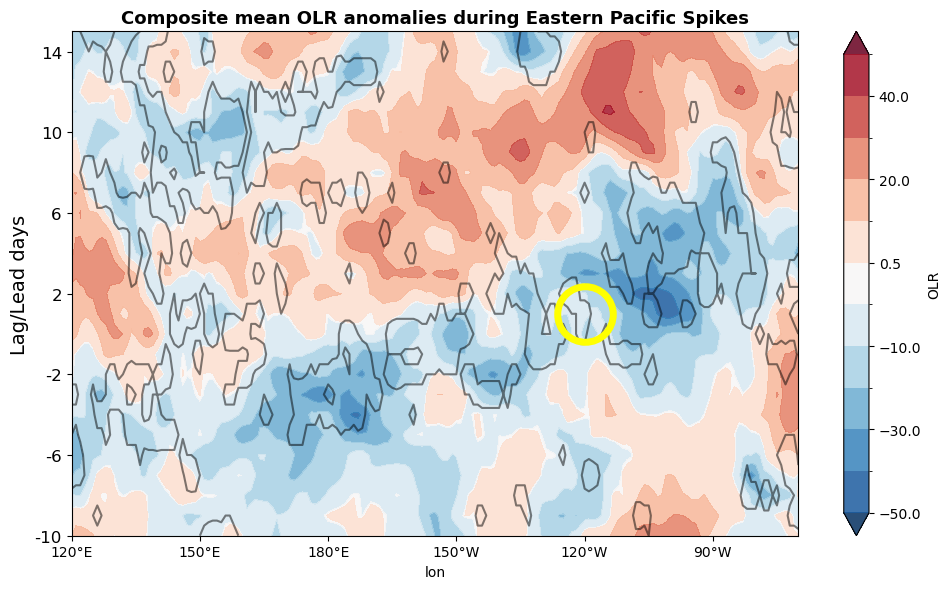

In [32]:
f()
wave.plot.contourf(levels=array([-50,-40,-30,-20,-10,-.5,.5,10,20,30,40,50]),extend='both',alpha=.85)
cs=sp.plot.contour(colors='black',levels=array([.25]),alpha=.5)
#plt.clabel(cs, inline=True, fontsize=8, fmt=lambda val: f"{val:.1f}")
ax = plt.gca()
#ax.set_xlim()
# Custom longitude ticks
xticks = np.arange(120, 300, 30)  # adjust as needed
xtick_labels = []
for lon in xticks:
    if lon <= 180:
        xtick_labels.append(f"{lon:.0f}°E")
    else:
        xtick_labels.append(f"{360 - lon:.0f}°W")

ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)


# ----- Custom y-axis ticks as "Day N" -----
time_values = wave['time'].values
# Number days from 1
days_since_start = (pd.to_datetime(time_values) - pd.to_datetime(time_values[0])).days + 1

yticks = ax.get_yticks()
# Map yticks (which are dates) to day numbers
ytick_labels = []
for tick in yticks:
    try:
        day_number = (pd.to_datetime(tick) - pd.to_datetime(time_values[0])).days + 1
        ytick_labels.append(f"Day {day_number}")
    except Exception:
        ytick_labels.append("")  # blank if outside range
ax.set_yticks(yticks)
ax.set_yticklabels(arange(0,28,4)-10,fontsize=12)
plt.ylabel('Lag/Lead days',fontsize=14)

x_mark = 240  # 120°W in 0–360 coords
y_mark = pd.to_datetime(time_values[0]) + pd.Timedelta(days=11)

ax.plot(x_mark, y_mark, marker='o', markersize=40,color='yellow',
        markerfacecolor='none', markeredgewidth=5)


plt.title('Composite mean OLR anomalies during Eastern Pacific Spikes', fontsize= 13, fontweight='bold')
plt.tight_layout()
plt.savefig('olr_anom.png',dpi=150)
plt.show()

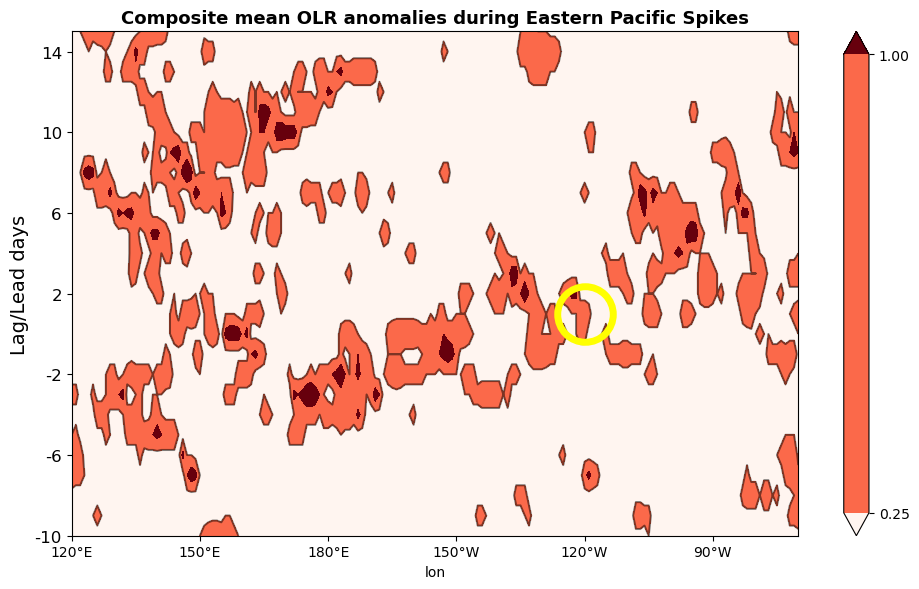

In [47]:
f()
#wave.plot.contourf(levels=array([-50,-40,-30,-20,-10,-.5,.5,10,20,30,40,50]),extend='both',alpha=.85)
plt.contourf(sp.lon,sp.time,sp,cmap='Reds',levels=array([.25,1]),extend='both')
plt.colorbar()
cs=sp.plot.contour(colors='black',levels=array([.25]),alpha=.5)
#plt.clabel(cs, inline=True, fontsize=8, fmt=lambda val: f"{val:.1f}")
ax = plt.gca()
#ax.set_xlim()
# Custom longitude ticks
xticks = np.arange(120, 300, 30)  # adjust as needed
xtick_labels = []
for lon in xticks:
    if lon <= 180:
        xtick_labels.append(f"{lon:.0f}°E")
    else:
        xtick_labels.append(f"{360 - lon:.0f}°W")

ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)


# ----- Custom y-axis ticks as "Day N" -----
time_values = wave['time'].values
# Number days from 1
days_since_start = (pd.to_datetime(time_values) - pd.to_datetime(time_values[0])).days + 1

yticks = ax.get_yticks()
# Map yticks (which are dates) to day numbers
ytick_labels = []
for tick in yticks:
    try:
        day_number = (pd.to_datetime(tick) - pd.to_datetime(time_values[0])).days + 1
        ytick_labels.append(f"Day {day_number}")
    except Exception:
        ytick_labels.append("")  # blank if outside range
ax.set_yticks(yticks)
ax.set_yticklabels(arange(0,28,4)-10,fontsize=12)
plt.ylabel('Lag/Lead days',fontsize=14)

x_mark = 240  # 120°W in 0–360 coords
y_mark = pd.to_datetime(time_values[0]) + pd.Timedelta(days=11)

ax.plot(x_mark, y_mark, marker='o', markersize=40,color='yellow',
        markerfacecolor='none', markeredgewidth=5)


plt.title('Composite mean OLR anomalies during Eastern Pacific Spikes', fontsize= 13, fontweight='bold')
plt.tight_layout()
plt.savefig('olr_anom2.png',dpi=150)
plt.show()

## 

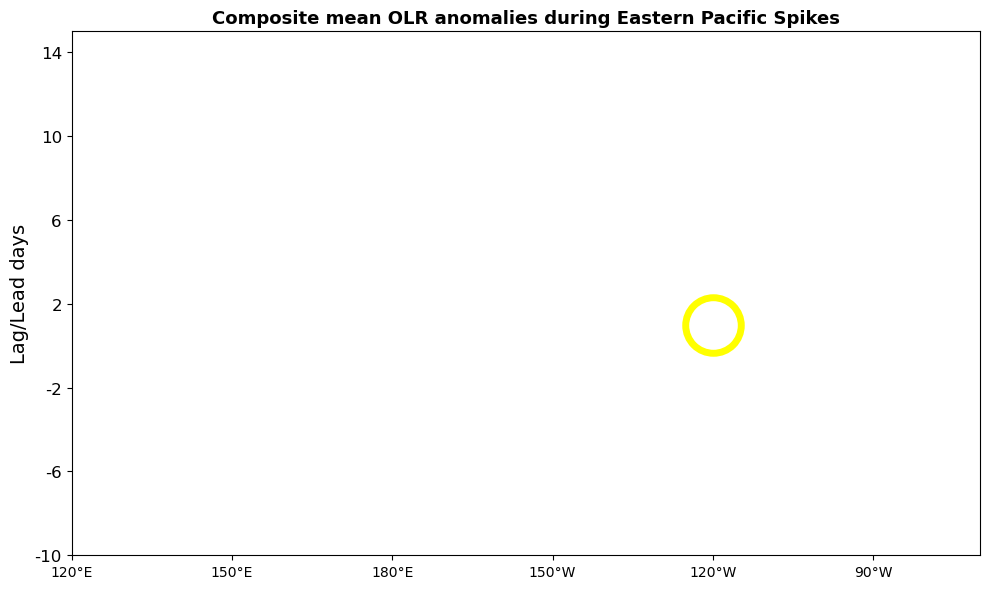

In [45]:
f()
#wave.plot.contourf(levels=array([-50,-40,-30,-20,-10,-.5,.5,10,20,30,40,50]),extend='both',alpha=.85)
plt.contourf(sp.lon,sp.time,sp,cmap='Reds',levels=array([25,60]),extend='max')
#cs=sp.plot.contour(colors='black',levels=array([.25]),alpha=.5)
#plt.clabel(cs, inline=True, fontsize=8, fmt=lambda val: f"{val:.1f}")
ax = plt.gca()
#ax.set_xlim()
# Custom longitude ticks
xticks = np.arange(120, 300, 30)  # adjust as needed
xtick_labels = []
for lon in xticks:
    if lon <= 180:
        xtick_labels.append(f"{lon:.0f}°E")
    else:
        xtick_labels.append(f"{360 - lon:.0f}°W")

ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)


# ----- Custom y-axis ticks as "Day N" -----
time_values = wave['time'].values
# Number days from 1
days_since_start = (pd.to_datetime(time_values) - pd.to_datetime(time_values[0])).days + 1

yticks = ax.get_yticks()
# Map yticks (which are dates) to day numbers
ytick_labels = []
for tick in yticks:
    try:
        day_number = (pd.to_datetime(tick) - pd.to_datetime(time_values[0])).days + 1
        ytick_labels.append(f"Day {day_number}")
    except Exception:
        ytick_labels.append("")  # blank if outside range
ax.set_yticks(yticks)
ax.set_yticklabels(arange(0,28,4)-10,fontsize=12)
plt.ylabel('Lag/Lead days',fontsize=14)

x_mark = 240  # 120°W in 0–360 coords
y_mark = pd.to_datetime(time_values[0]) + pd.Timedelta(days=11)

ax.plot(x_mark, y_mark, marker='o', markersize=40,color='yellow',
        markerfacecolor='none', markeredgewidth=5)


plt.title('Composite mean OLR anomalies during Eastern Pacific Spikes', fontsize= 13, fontweight='bold')
plt.tight_layout()
plt.savefig('olr_anom3.png',dpi=150)
plt.show()